# HomeWork 1
# Daniel Mariano | 801405021
# Github: https://github.com/DMariano0912/DeepLearningECGR4106/tree/main/HW1

In [1]:
#Imports

import torch, torchvision
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

**Models and Training:**

In [2]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

full_train = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=None)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

train_size = int(0.8 * len(full_train))
val_size = len(full_train) - train_size

train_data, val_data = random_split(full_train, [train_size, val_size])

train_data.dataset.transform = transform_train
val_data.dataset.transform = transform_test

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
val_loader = DataLoader(val_data, batch_size=128)
test_loader = DataLoader(test_dataset, batch_size=128)

100%|██████████| 170M/170M [00:06<00:00, 25.9MB/s]


In [22]:
#Model Training
def train_model(model, train_loader, val_loader, epochs=30):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_losses, val_losses, val_accs = [], [], []

    for epoch in range(epochs):
        model.train()
        running_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_losses.append(running_loss / len(train_loader))

        model.eval()
        correct, total = 0, 0
        val_loss = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                _, preds = outputs.max(1)
                total += labels.size(0)
                correct += preds.eq(labels).sum().item()

        val_losses.append(val_loss / len(val_loader))
        val_accs.append(100 * correct / total)

        print(f"Epoch {epoch+1}: Val Acc={val_accs[-1]:.2f}")

    return train_losses, val_losses, val_accs

#Problem 3 Module Training:
def train_model_scheduler(model, train_loader, val_loader, epochs=50):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.1)

    train_losses, val_losses, val_accs = [], [], []

    for epoch in range(epochs):
        model.train()
        running_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        scheduler.step()

        train_losses.append(running_loss / len(train_loader))

        model.eval()
        correct, total = 0, 0
        val_loss = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                _, preds = outputs.max(1)
                total += labels.size(0)
                correct += preds.eq(labels).sum().item()

        val_losses.append(val_loss / len(val_loader))
        val_accs.append(100 * correct / total)

        print(f"Epoch {epoch+1}: Val Acc={val_accs[-1]:.2f}")

    return train_losses, val_losses, val_accs

In [21]:
#Accuracy Setup
def test_accuracy(model, loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = outputs.max(1)

            total += labels.size(0)
            correct += preds.eq(labels).sum().item()

    acc = 100 * correct / total
    print(f"Test Accuracy: {acc:.2f}%")
    return acc

**Graph Functions:**

In [5]:
def plot_curves(train_losses, val_losses, val_accs, title="Model"):
    epochs = range(1, len(train_losses)+1)

    plt.figure()
    plt.plot(epochs, train_losses, label="Train Loss")
    plt.plot(epochs, val_losses, label="Val Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title(f"{title} Loss")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(epochs, val_accs, label="Val Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy (%)")
    plt.title(f"{title} Accuracy")
    plt.legend()
    plt.show()

In [6]:
def plot_confusion_matrix(model, loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()

    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = outputs.max(1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

#**Problem 1**

In [7]:
class AlexNetCIFAR(nn.Module):
    def __init__(self, dropout=0.0):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*8*8, 512), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

Outputs:

Epoch 1: Train Loss=1.520, Val Acc=58.72
Epoch 2: Train Loss=1.063, Val Acc=67.66
Epoch 3: Train Loss=0.838, Val Acc=70.83
Epoch 4: Train Loss=0.670, Val Acc=73.99
Epoch 5: Train Loss=0.526, Val Acc=74.38
Epoch 6: Train Loss=0.395, Val Acc=76.01
Epoch 7: Train Loss=0.303, Val Acc=75.30
Epoch 8: Train Loss=0.230, Val Acc=75.53
Epoch 9: Train Loss=0.174, Val Acc=76.25
Epoch 10: Train Loss=0.140, Val Acc=75.10
Epoch 11: Train Loss=0.122, Val Acc=75.88
Epoch 12: Train Loss=0.103, Val Acc=74.71
Epoch 13: Train Loss=0.106, Val Acc=75.46
Epoch 14: Train Loss=0.088, Val Acc=74.75
Epoch 15: Train Loss=0.089, Val Acc=75.43
Epoch 16: Train Loss=0.075, Val Acc=75.71
Epoch 17: Train Loss=0.074, Val Acc=74.56
Epoch 18: Train Loss=0.080, Val Acc=75.91
Epoch 19: Train Loss=0.069, Val Acc=74.75
Epoch 20: Train Loss=0.062, Val Acc=75.89
Epoch 21: Train Loss=0.060, Val Acc=75.23
Epoch 22: Train Loss=0.067, Val Acc=75.58
Epoch 23: Train Loss=0.060, Val Acc=74.93
Epoch 24: Train Loss=0.066, Val Acc=75.27
E

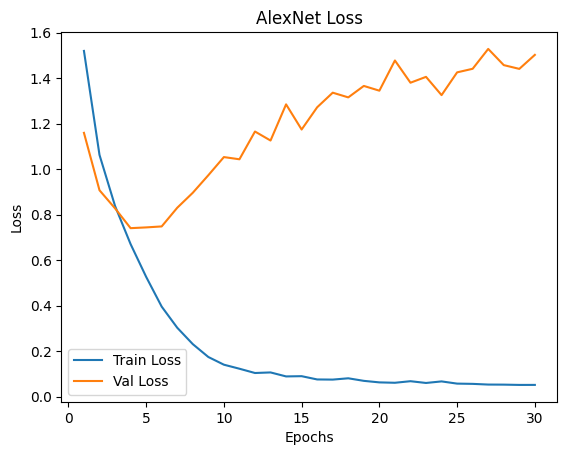

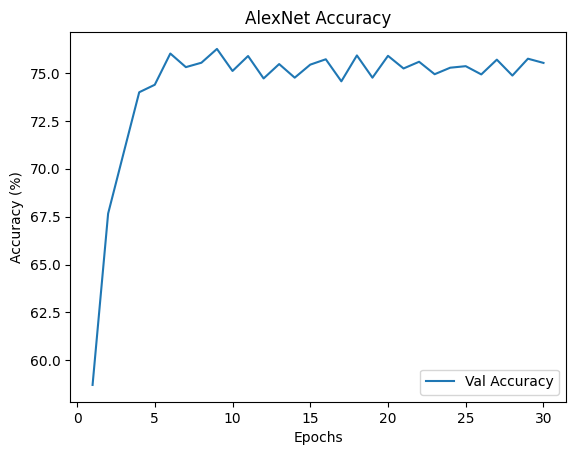

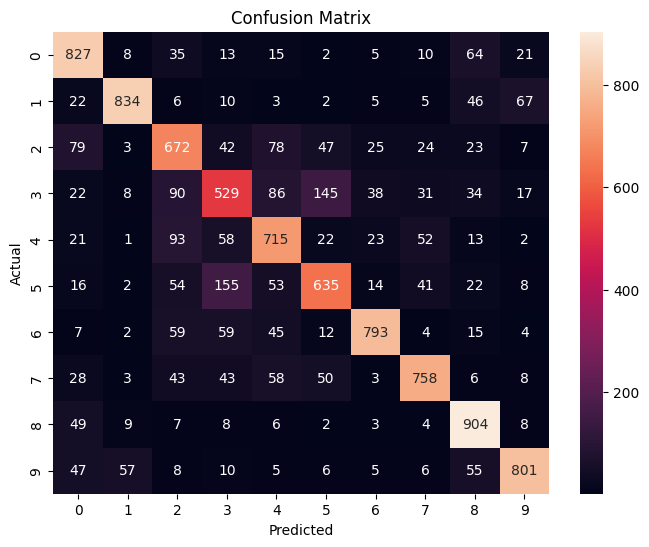

Test Accuracy: 74.68%


In [8]:
alex = AlexNetCIFAR(dropout=0.3)
train_l, val_l, val_a = train_model(alex, train_loader, val_loader)

plot_curves(train_l, val_l, val_a, "AlexNet")
plot_confusion_matrix(alex, test_loader)

alex_acc = test_accuracy(alex, test_loader)

0.5 Testing:

Epoch 1: Train Loss=1.603, Val Acc=56.51
Epoch 2: Train Loss=1.169, Val Acc=65.46
Epoch 3: Train Loss=0.946, Val Acc=71.52
Epoch 4: Train Loss=0.791, Val Acc=73.87
Epoch 5: Train Loss=0.676, Val Acc=74.75
Epoch 6: Train Loss=0.566, Val Acc=74.65
Epoch 7: Train Loss=0.474, Val Acc=75.80
Epoch 8: Train Loss=0.391, Val Acc=75.75
Epoch 9: Train Loss=0.329, Val Acc=75.61
Epoch 10: Train Loss=0.276, Val Acc=76.15
Epoch 11: Train Loss=0.237, Val Acc=76.57
Epoch 12: Train Loss=0.205, Val Acc=76.01
Epoch 13: Train Loss=0.184, Val Acc=76.33
Epoch 14: Train Loss=0.168, Val Acc=75.64
Epoch 15: Train Loss=0.156, Val Acc=76.73
Epoch 16: Train Loss=0.146, Val Acc=76.67
Epoch 17: Train Loss=0.134, Val Acc=76.55
Epoch 18: Train Loss=0.126, Val Acc=75.78
Epoch 19: Train Loss=0.118, Val Acc=76.84
Epoch 20: Train Loss=0.113, Val Acc=76.47
Epoch 21: Train Loss=0.101, Val Acc=76.52
Epoch 22: Train Loss=0.098, Val Acc=76.01
Epoch 23: Train Loss=0.112, Val Acc=76.13
Epoch 24: Train Loss=0.103, Val Acc=76.39
E

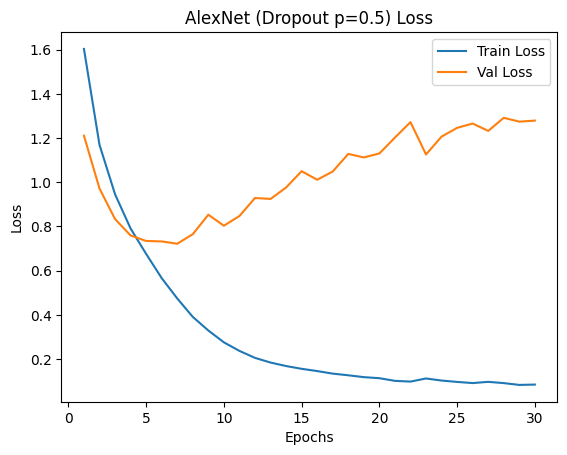

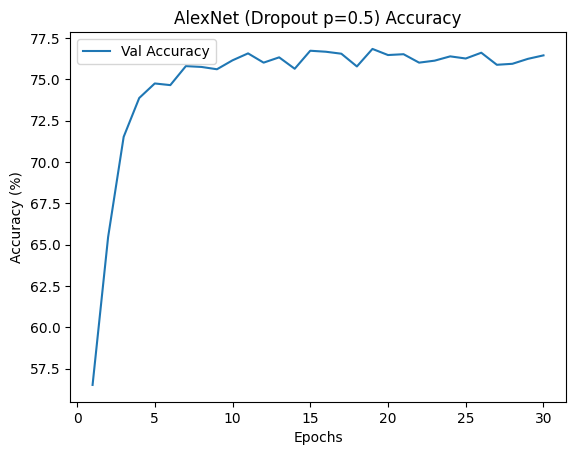

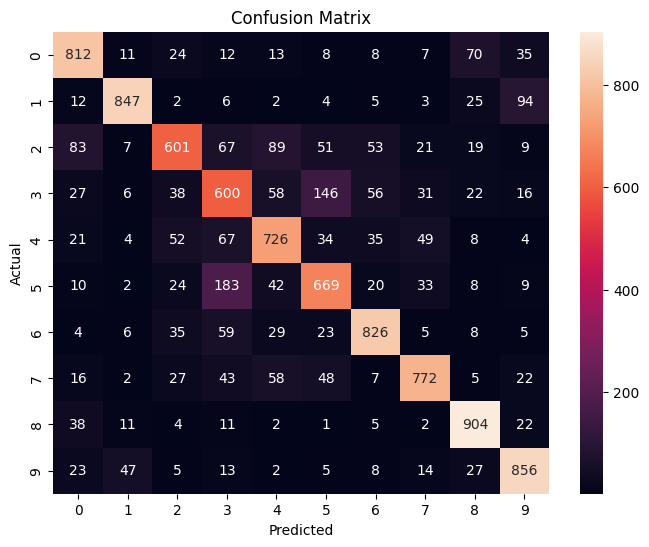

In [9]:
alex_d5 = AlexNetCIFAR(dropout=0.5)

train_l_d5, val_l_d5, val_a_d5 = train_model(alex_d5, train_loader, val_loader)

plot_curves(train_l_d5, val_l_d5, val_a_d5, "AlexNet (Dropout p=0.5)")
plot_confusion_matrix(alex_d5, test_loader)

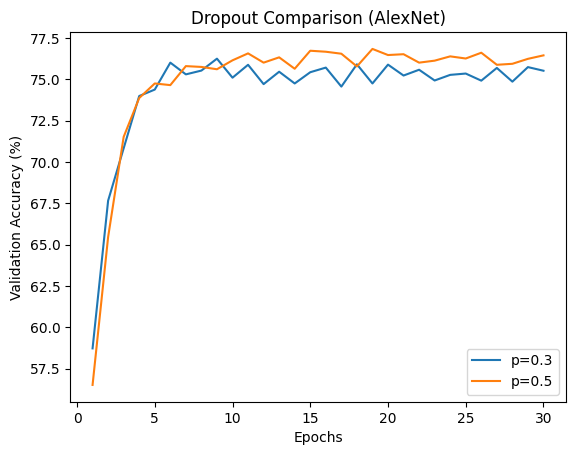

In [10]:
epochs = range(1, len(train_l)+1)

plt.figure()
plt.plot(epochs, val_a, label="p=0.3")
plt.plot(epochs, val_a_d5, label="p=0.5")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy (%)")
plt.title("Dropout Comparison (AlexNet)")
plt.legend()
plt.show()

#**Problem 2**

In [11]:
class VGG_CIFAR(nn.Module):
    def __init__(self, dropout=0.0):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*4*4, 512), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

Outputs:

Epoch 1: Train Loss=1.555, Val Acc=56.31
Epoch 2: Train Loss=1.111, Val Acc=65.38
Epoch 3: Train Loss=0.880, Val Acc=70.86
Epoch 4: Train Loss=0.727, Val Acc=73.95
Epoch 5: Train Loss=0.604, Val Acc=74.27
Epoch 6: Train Loss=0.502, Val Acc=76.43
Epoch 7: Train Loss=0.403, Val Acc=76.41
Epoch 8: Train Loss=0.306, Val Acc=77.51
Epoch 9: Train Loss=0.245, Val Acc=76.25
Epoch 10: Train Loss=0.200, Val Acc=77.48
Epoch 11: Train Loss=0.159, Val Acc=76.86
Epoch 12: Train Loss=0.131, Val Acc=77.58
Epoch 13: Train Loss=0.109, Val Acc=77.12
Epoch 14: Train Loss=0.095, Val Acc=77.96
Epoch 15: Train Loss=0.095, Val Acc=77.53
Epoch 16: Train Loss=0.092, Val Acc=76.28
Epoch 17: Train Loss=0.082, Val Acc=77.42
Epoch 18: Train Loss=0.080, Val Acc=77.85
Epoch 19: Train Loss=0.063, Val Acc=76.44
Epoch 20: Train Loss=0.077, Val Acc=76.75
Epoch 21: Train Loss=0.073, Val Acc=76.86
Epoch 22: Train Loss=0.071, Val Acc=77.12
Epoch 23: Train Loss=0.063, Val Acc=77.42
Epoch 24: Train Loss=0.070, Val Acc=77.11
E

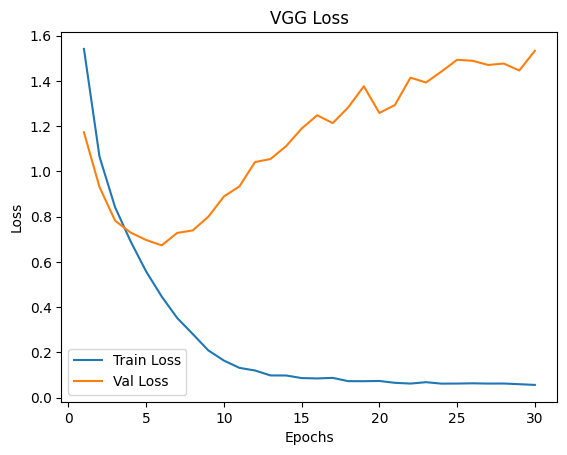

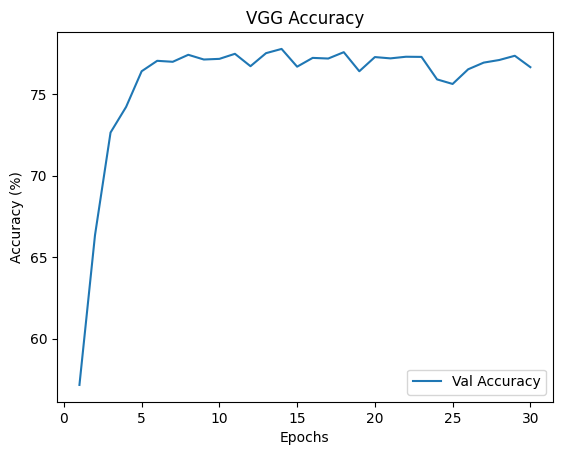

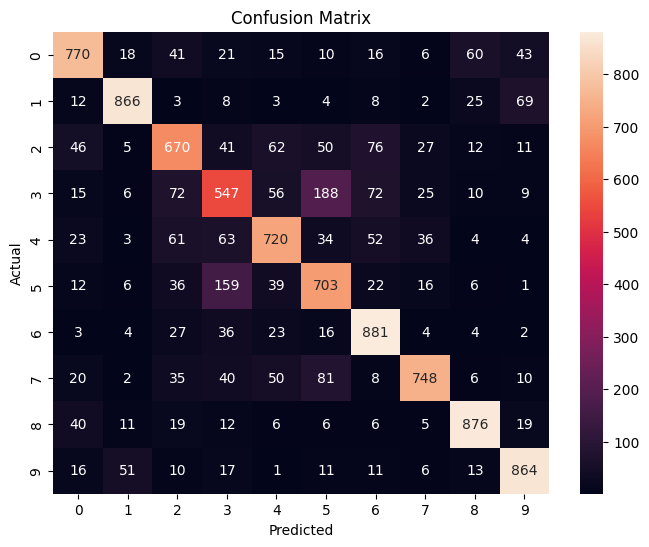

Test Accuracy: 76.45%


In [16]:
vgg = VGG_CIFAR(dropout=0.3)
train_l_vgg, val_l_vgg, val_a_vgg = train_model(vgg, train_loader, val_loader)
plot_curves(train_l, val_l, val_a, "VGG")
plot_confusion_matrix(vgg, test_loader)

vgg_acc = test_accuracy(vgg, test_loader)

0.5 Testing:

Epoch 1: Train Loss=1.563, Val Acc=57.29
Epoch 2: Train Loss=1.113, Val Acc=65.67
Epoch 3: Train Loss=0.893, Val Acc=71.44
Epoch 4: Train Loss=0.741, Val Acc=74.27
Epoch 5: Train Loss=0.624, Val Acc=74.36
Epoch 6: Train Loss=0.526, Val Acc=75.95
Epoch 7: Train Loss=0.437, Val Acc=76.89
Epoch 8: Train Loss=0.349, Val Acc=77.71
Epoch 9: Train Loss=0.287, Val Acc=78.48
Epoch 10: Train Loss=0.232, Val Acc=77.68
Epoch 11: Train Loss=0.190, Val Acc=77.81
Epoch 12: Train Loss=0.158, Val Acc=77.72
Epoch 13: Train Loss=0.136, Val Acc=77.92
Epoch 14: Train Loss=0.126, Val Acc=76.97
Epoch 15: Train Loss=0.110, Val Acc=77.00
Epoch 16: Train Loss=0.106, Val Acc=76.41
Epoch 17: Train Loss=0.099, Val Acc=77.70
Epoch 18: Train Loss=0.088, Val Acc=77.99
Epoch 19: Train Loss=0.095, Val Acc=77.83
Epoch 20: Train Loss=0.081, Val Acc=77.52
Epoch 21: Train Loss=0.076, Val Acc=77.50
Epoch 22: Train Loss=0.092, Val Acc=77.92
Epoch 23: Train Loss=0.073, Val Acc=78.05
Epoch 24: Train Loss=0.076, Val Acc=77.21
E

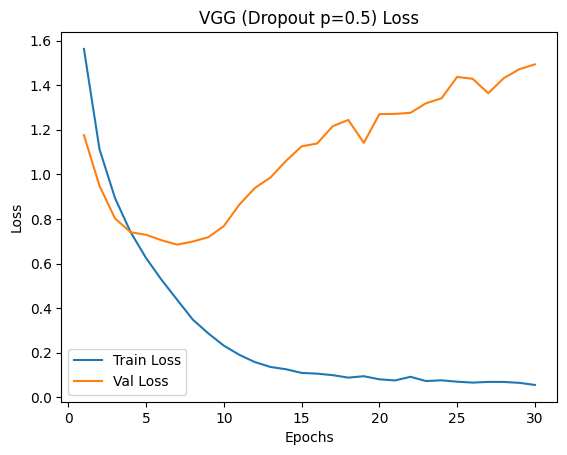

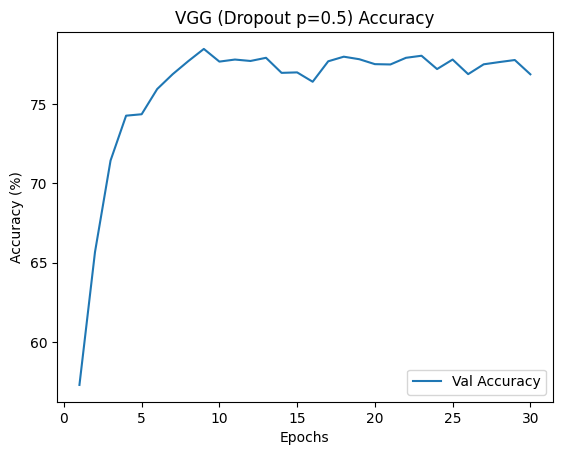

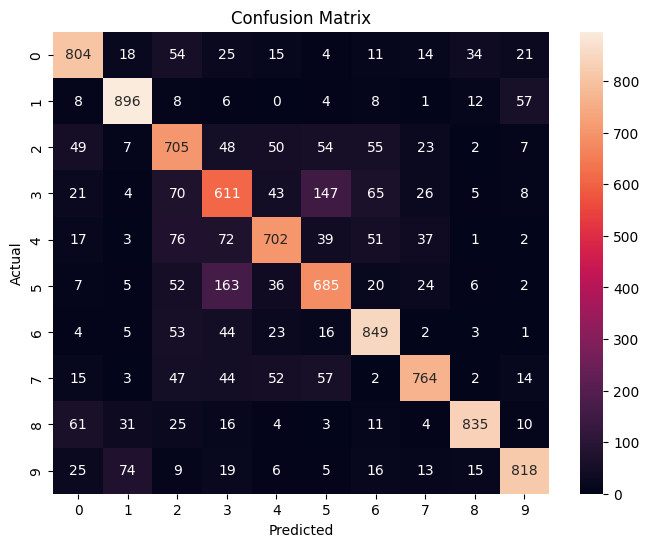

In [13]:
vgg_d5 = VGG_CIFAR(dropout=0.5)

train_l_vgg_d5, val_l_vgg_d5, val_a_vgg_d5 = train_model(vgg_d5, train_loader, val_loader)

plot_curves(train_l_vgg_d5, val_l_vgg_d5, val_a_vgg_d5, "VGG (Dropout p=0.5)")
plot_confusion_matrix(vgg_d5, test_loader)

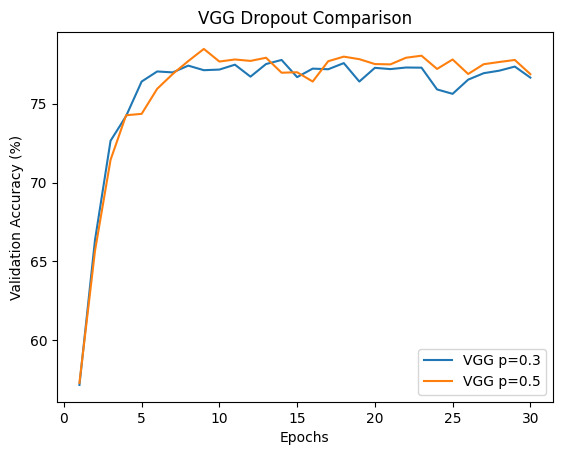

In [14]:
epochs = range(1, len(train_l)+1)

plt.figure()
plt.plot(epochs, val_a, label="VGG p=0.3")
plt.plot(epochs, val_a_vgg_d5, label="VGG p=0.5")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy (%)")
plt.title("VGG Dropout Comparison")
plt.legend()
plt.show()

Cross Model Comparison:

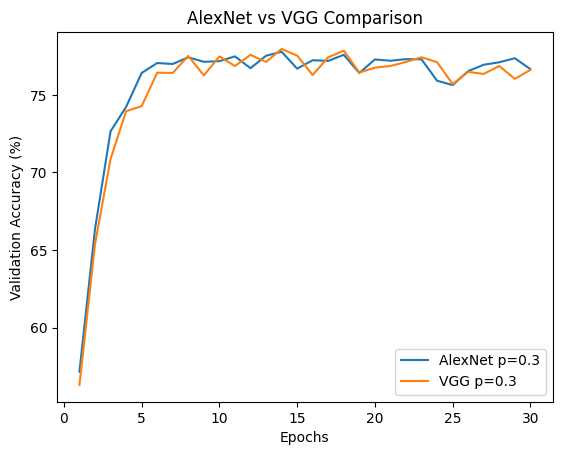

In [17]:
epochs = range(1, len(val_a)+1)

plt.figure()
plt.plot(epochs, val_a, label="AlexNet p=0.3")
plt.plot(epochs, val_a_vgg, label="VGG p=0.3")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy (%)")
plt.title("AlexNet vs VGG Comparison")
plt.legend()
plt.show()

#**Problem 3**

In [23]:
class BasicBlock(nn.Module):
    def __init__(self, in_c, out_c, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(in_c, out_c, 3, stride, 1)
        self.bn1 = nn.BatchNorm2d(out_c)
        self.conv2 = nn.Conv2d(out_c, out_c, 3, 1, 1)
        self.bn2 = nn.BatchNorm2d(out_c)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_c != out_c:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_c, out_c, 1, stride),
                nn.BatchNorm2d(out_c)
            )

    def forward(self, x):
        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return torch.relu(out)

#ResNet18
class ResNet18(nn.Module):
    def __init__(self, dropout=0.0):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 64, 3, 1, 1)
        self.bn1 = nn.BatchNorm2d(64)

        self.layer1 = self._make_layer(64, 64, 2)
        self.layer2 = self._make_layer(64, 128, 2, stride=2)
        self.layer3 = self._make_layer(128, 256, 2, stride=2)
        self.layer4 = self._make_layer(256, 512, 2, stride=2)

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(512, 10)

    def _make_layer(self, in_c, out_c, blocks, stride=1):
        layers = [BasicBlock(in_c, out_c, stride)]
        for _ in range(1, blocks):
            layers.append(BasicBlock(out_c, out_c))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = torch.relu(self.bn1(self.conv1(x)))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        return self.fc(x)

#ResNet11
class ResNet11(nn.Module):
    def __init__(self, dropout=0.0):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 64, 3, 1, 1)
        self.bn1 = nn.BatchNorm2d(64)

        self.layer1 = BasicBlock(64, 64)
        self.layer2 = BasicBlock(64, 128, stride=2)
        self.layer3 = BasicBlock(128, 256, stride=2)
        self.layer4 = BasicBlock(256, 512, stride=2)

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(512, 10)

    def forward(self, x):
        x = torch.relu(self.bn1(self.conv1(x)))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        return self.fc(x)

Outputs:

Part A:

Epoch 1: Val Acc=59.03
Epoch 2: Val Acc=65.05
Epoch 3: Val Acc=74.04
Epoch 4: Val Acc=78.42
Epoch 5: Val Acc=76.29
Epoch 6: Val Acc=78.73
Epoch 7: Val Acc=80.68
Epoch 8: Val Acc=80.76
Epoch 9: Val Acc=80.39
Epoch 10: Val Acc=81.28
Epoch 11: Val Acc=79.67
Epoch 12: Val Acc=83.30
Epoch 13: Val Acc=80.94
Epoch 14: Val Acc=82.73
Epoch 15: Val Acc=81.23
Epoch 16: Val Acc=81.79
Epoch 17: Val Acc=83.38
Epoch 18: Val Acc=83.74
Epoch 19: Val Acc=82.77
Epoch 20: Val Acc=83.39
Epoch 21: Val Acc=85.51
Epoch 22: Val Acc=85.94
Epoch 23: Val Acc=85.95
Epoch 24: Val Acc=86.01
Epoch 25: Val Acc=86.14
Epoch 26: Val Acc=86.27
Epoch 27: Val Acc=86.31
Epoch 28: Val Acc=86.22
Epoch 29: Val Acc=86.27
Epoch 30: Val Acc=86.26
Epoch 31: Val Acc=86.34
Epoch 32: Val Acc=86.28
Epoch 33: Val Acc=86.32
Epoch 34: Val Acc=86.13
Epoch 35: Val Acc=86.20
Epoch 36: Val Acc=86.04
Epoch 37: Val Acc=86.06
Epoch 38: Val Acc=86.17
Epoch 39: Val Acc=86.15
Epoch 40: Val Acc=85.95
Epoch 41: Val Acc=86.07
Epoch 42: Val Acc=86.25
E

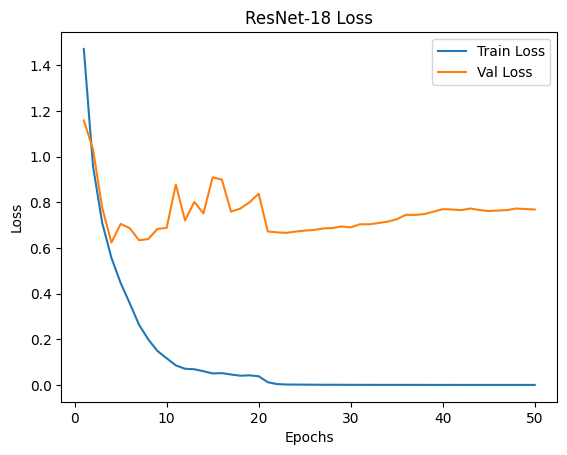

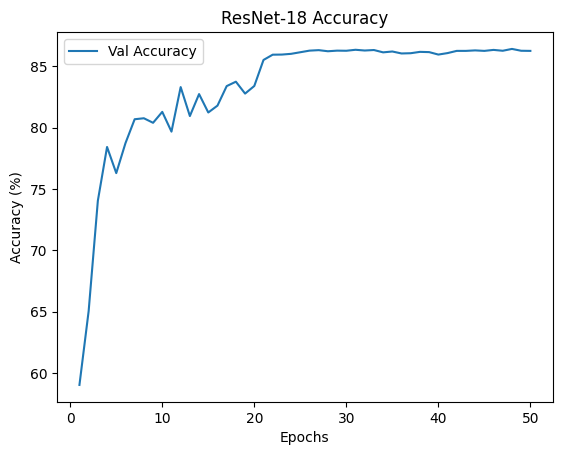

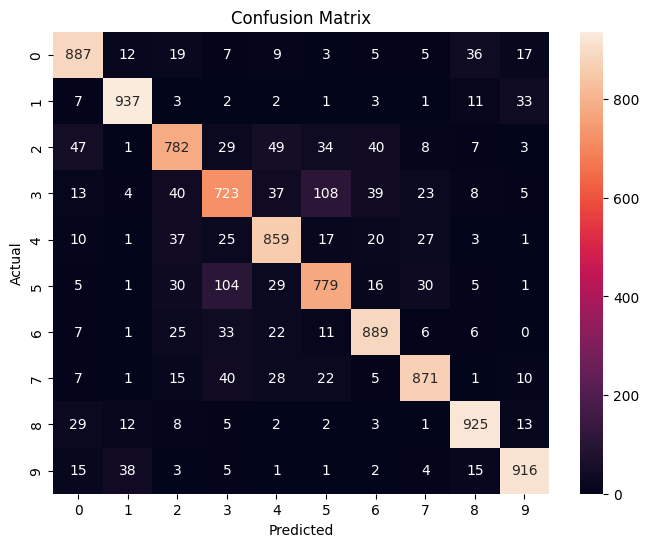

In [25]:
resnet18 = ResNet18(dropout=0.3)

train_l_r18, val_l_r18, val_a_r18 = train_model_scheduler(
    resnet18,
    train_loader,
    val_loader,
    epochs=50
)

plot_curves(train_l_r18, val_l_r18, val_a_r18, "ResNet-18")

plot_confusion_matrix(resnet18, test_loader)

Epoch 1: Val Acc=49.41
Epoch 2: Val Acc=67.44
Epoch 3: Val Acc=69.62
Epoch 4: Val Acc=76.62
Epoch 5: Val Acc=77.16
Epoch 6: Val Acc=77.21
Epoch 7: Val Acc=78.35
Epoch 8: Val Acc=78.64
Epoch 9: Val Acc=75.66
Epoch 10: Val Acc=79.96
Epoch 11: Val Acc=80.33
Epoch 12: Val Acc=75.61
Epoch 13: Val Acc=80.80
Epoch 14: Val Acc=81.25
Epoch 15: Val Acc=76.14
Epoch 16: Val Acc=81.66
Epoch 17: Val Acc=81.15
Epoch 18: Val Acc=80.17
Epoch 19: Val Acc=79.72
Epoch 20: Val Acc=81.96
Epoch 21: Val Acc=84.07
Epoch 22: Val Acc=84.02
Epoch 23: Val Acc=84.02
Epoch 24: Val Acc=84.13
Epoch 25: Val Acc=84.36
Epoch 26: Val Acc=84.33
Epoch 27: Val Acc=84.38
Epoch 28: Val Acc=84.37
Epoch 29: Val Acc=84.39
Epoch 30: Val Acc=84.55
Epoch 31: Val Acc=84.49
Epoch 32: Val Acc=84.39
Epoch 33: Val Acc=84.38
Epoch 34: Val Acc=84.45
Epoch 35: Val Acc=84.49
Epoch 36: Val Acc=84.71
Epoch 37: Val Acc=84.54
Epoch 38: Val Acc=84.58
Epoch 39: Val Acc=84.38
Epoch 40: Val Acc=84.69
Epoch 41: Val Acc=84.55
Epoch 42: Val Acc=84.57
E

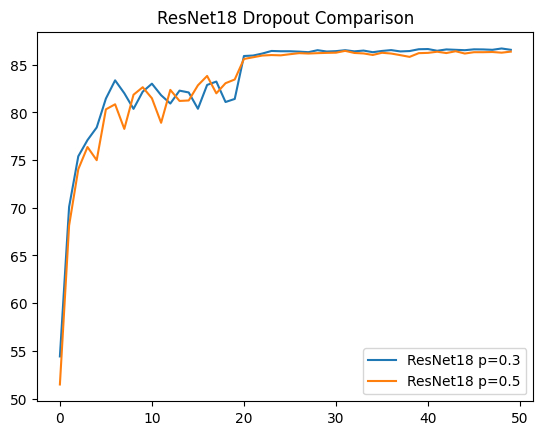

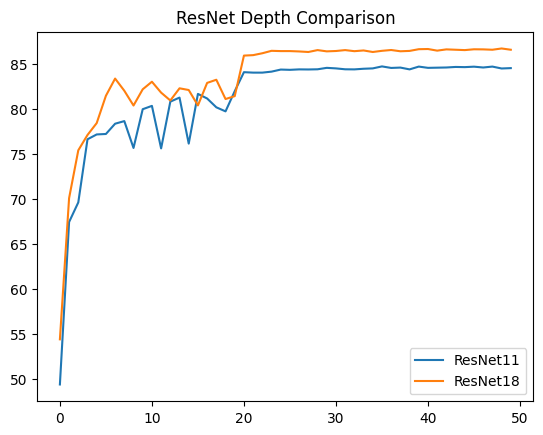

Test Accuracy: 83.54%
Test Accuracy: 85.84%


In [24]:
res11_d3 = ResNet11(dropout=0.3)
train_l_r11_d3, val_l_r11_d3, val_a_r11_d3 = train_model_scheduler(res11_d3, train_loader, val_loader, epochs=50)

res11_d5 = ResNet11(dropout=0.5)
train_l_r11_d5, val_l_r11_d5, val_a_r11_d5 = train_model_scheduler(res11_d5, train_loader, val_loader, epochs=50)

res18_d3 = ResNet18(dropout=0.3)
train_l_r18_d3, val_l_r18_d3, val_a_r18_d3 = train_model_scheduler(res18_d3, train_loader, val_loader, epochs=50)

res18_d5 = ResNet18(dropout=0.5)
train_l_r18_d5, val_l_r18_d5, val_a_r18_d5 = train_model_scheduler(res18_d5, train_loader, val_loader, epochs=50)

plt.plot(val_a_r18_d3, label="ResNet18 p=0.3")
plt.plot(val_a_r18_d5, label="ResNet18 p=0.5")
plt.legend()
plt.title("ResNet18 Dropout Comparison")
plt.show()

plt.plot(val_a_r11_d3, label="ResNet11")
plt.plot(val_a_r18_d3, label="ResNet18")
plt.legend()
plt.title("ResNet Depth Comparison")
plt.show()

res11_acc = test_accuracy(res11_d3, test_loader)
res18_acc = test_accuracy(res18_d3, test_loader)

Comparison Output:

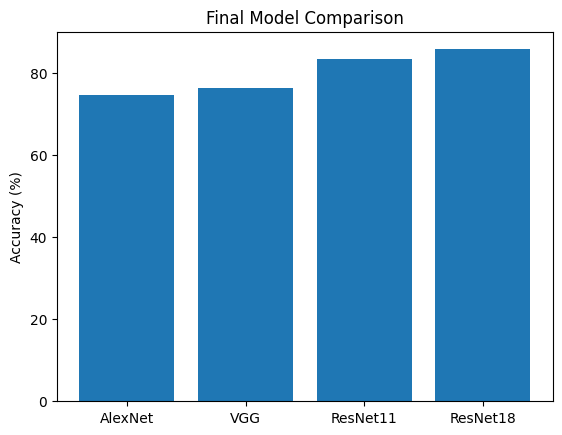

In [26]:
models = ["AlexNet", "VGG", "ResNet11", "ResNet18"]
accuracies = [alex_acc, vgg_acc, res11_acc, res18_acc]

plt.figure()
plt.bar(models, accuracies)
plt.title("Final Model Comparison")
plt.ylabel("Accuracy (%)")
plt.show()